# EDA

In [18]:
%cd /home/artsiom/MyProjects/spam-classifier

/home/artsiom/MyProjects/spam-classifier


In [19]:
from src.data import load_data, add_features
df = add_features(load_data())
df.head()

,text,spam,clean_text,length,punct_percent,caps_ratio,digit_percent
0,Subject: naturally irresistible your corporate...,1,naturally irresistible corporate identity lt r...,1484,9.164420,0.067385,0.202156
1,Subject: the stock trading gunslinger fanny i...,1,stock trading gunslinger fanny merrill muzo co...,598,0.167224,0.167224,0.000000
2,Subject: unbelievable new homes made easy im ...,1,unbelievable new home made easy im wanting sho...,448,1.785714,0.223214,2.232143
3,Subject: 4 color printing special request add...,1,4 color printing special request additional in...,500,5.000000,0.200000,6.000000
4,"Subject: do not have money , get software cds ...",1,money get software cd software compatibility g...,235,5.531915,0.425532,0.000000


## Базовая статистика

In [21]:
df.info()
print(df['spam'].value_counts())
print(f"Дисбаланс: {(df['spam']==0).sum()/(df['spam']==1).sum():.2f}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   text           5728 non-null   object 
 1   spam           5728 non-null   int64  
 2   clean_text     5728 non-null   object 
 3   length         5728 non-null   int64  
 4   punct_percent  5728 non-null   float64
 5   caps_ratio     5728 non-null   float64
 6   digit_percent  5728 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 313.4+ KB
spam
0    4360
1    1368
Name: count, dtype: int64
Дисбаланс: 3.19


## Распределение признаков по классам

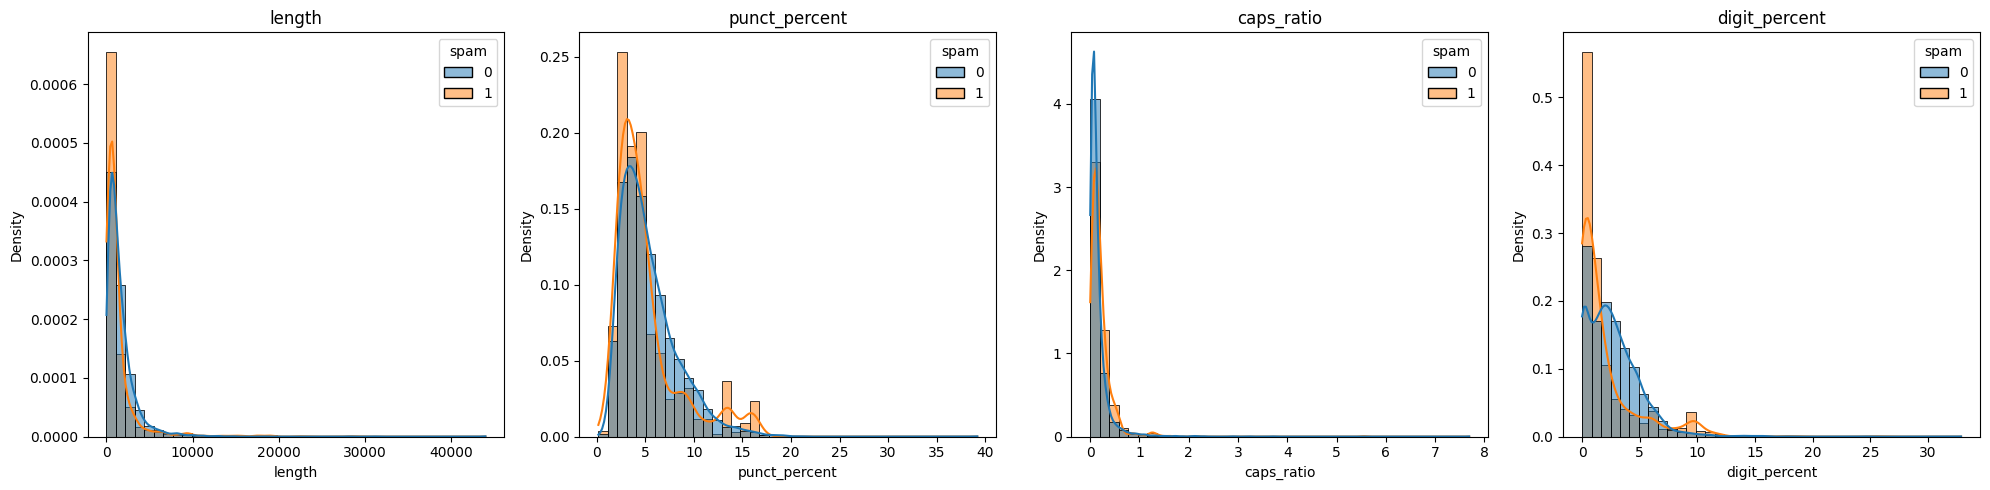

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, ['length', 'punct_percent', 'caps_ratio', 'digit_percent']):
    sns.histplot(data=df, x=col, hue='spam', bins=40, kde=True, ax=ax, stat='density', common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Корреляция числовых признаков

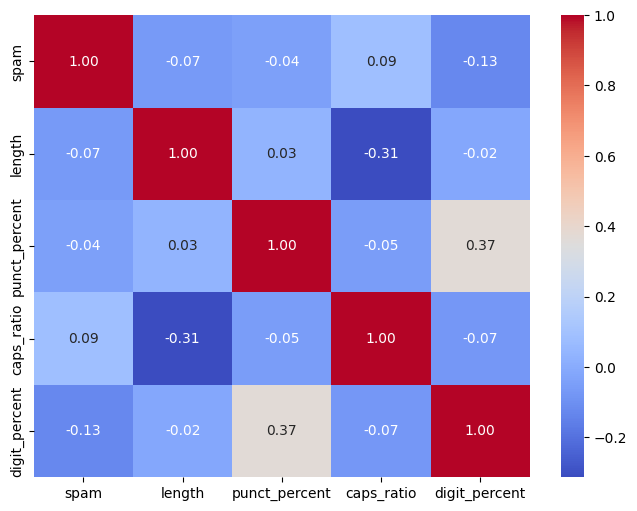

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['spam', 'length', 'punct_percent', 'caps_ratio', 'digit_percent']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Очистка

In [25]:
print("ДО:", df['text'].iloc[0][:300])
print("ПОСЛЕ:", df['clean_text'].iloc[0][:300])

ДО: Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that h
ПОСЛЕ: naturally irresistible corporate identity lt really hard recollect company market full suqgestions information isoverwhelminq good catchy logo stylish statlonery outstanding website make task much easier promise havinq ordered iogo company automaticaily become world ieader isguite ciear without good
